In [1]:
# limit the thread used by numpy for better parallelization
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.Interferometer import *
from Triangle.TDI import *
from Triangle.Glitch import *
from Triangle.GW import *
from Triangle.Cosmology import LuminosityDistance, z_dl

import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'

# import multiprocessing
# if __name__ == "__main__":
#     multiprocessing.set_start_method("fork")
# print("number of cpus =", multiprocessing.cpu_count())
# pool = multiprocessing.Pool(processes=multiprocessing.cpu_count())

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [3]:
class FastGBTDIResponse:
    eta_strings = {"12": [(1.0, [])], "13": [(1.0, [])], "23": [(1.0, [])], "21": [(1.0, [])], "31": [(1.0, [])], "32": [(1.0, [])]}
    X2_strings = {
        "12": [(1.0, []), (-1.0, ["13", "31"]), (-1.0, ["13", "31", "12", "21"]), (1.0, ["12", "21", "13", "31", "13", "31"])],
        "23": [],
        "31": [(-1.0, ["13"]), (1.0, ["12", "21", "13"]), (1.0, ["12", "21", "13", "31", "13"]), (-1.0, ["13", "31", "12", "21", "12", "21", "13"])],
        "21": [(1.0, ["12"]), (-1.0, ["13", "31", "12"]), (-1.0, ["13", "31", "12", "21", "12"]), (1.0, ["12", "21", "13", "31", "13", "31", "12"])],
        "32": [],
        "13": [(-1.0, []), (1.0, ["12", "21"]), (1.0, ["12", "21", "13", "31"]), (-1.0, ["13", "31", "12", "21", "12", "21"])],
    }
    GB_param_names = ["A", "f0", "fdot0", "phase0", "inclination", "longitude", "latitude", "psi"]

    def __init__(self, orbit, Pstring, tcb_times, Nsparse=512, drop_points=0, use_gpu=False):
        """
        Args:
            orbit: an Orbit object
            Pstring: a string specifying the TDI channel
            tcb_times: TCB times at which the TDI responses will be calculated
        """
        self.orbit_object = orbit
        self.tcb_times = tcb_times.copy()
        self.Ntime = len(tcb_times)
        self.Nsparse = Nsparse
        self.drop_points = drop_points
        if use_gpu:
            self.xp = xp
        else:
            self.xp = np
        self.COS = self.xp.cos 
        self.SIN = self.xp.sin 
        self.EXP = self.xp.exp 
        self.SINC = self.xp.sinc
        self.MATMUL = self.xp.matmul
        self.NX = self.xp.newaxis

        # the orbit functions use numpy array as input
        self.sparse_times = np.linspace(tcb_times[0], tcb_times[-1], Nsparse) # (Nsparse)

        # calculate sparsely sampled time series associated with orbit and time delays
        self.Ndelay_dict = {}  # each item is an integer
        for key in MOSA_labels:
            self.Ndelay_dict[key] = len(Pstring[key])

        self.delay_factor_dict = {}  # each item is a xp array of shape (Ndelay)
        for key in MOSA_labels:
            self.delay_factor_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delay_factor_dict[key].append(Pstring[key][Idelay][0])
            self.delay_factor_dict[key] = self.xp.array(self.delay_factor_dict[key])

        self.delay_dict = {}  # each item is a numpy array of shape (Ndelay, Nsparse), not converted to xp array yet 
        for key in MOSA_labels:
            self.delay_dict[key] = []
            Pij = Pstring[key]
            for Idelay in range(self.Ndelay_dict[key]):
                d_Idelay = np.zeros_like(self.sparse_times)
                N_single_delay = len(Pij[Idelay][1])
                for I_single_delay in range(N_single_delay): # nested delay is not necessary
                    if Pij[Idelay][1][I_single_delay][0] == "-":
                        d_Idelay += -orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay][1:]](self.sparse_times)
                    else:
                        d_Idelay += orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay]](self.sparse_times)
                self.delay_dict[key].append(d_Idelay)

        self.delayed_dij_dict = {}  # dij delayed by d_Idelay, each item is a xp array of shape (Ndelay, Nsparse)
        for key in MOSA_labels:
            self.delayed_dij_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_dij_dict[key].append(orbit.LTTfunctions()[key](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_dij_dict[key] = self.xp.array(self.delayed_dij_dict[key])

        # calculate time series associated with orbit
        self.arm_vector_dict = assign_function_for_MOSAs(
            functions=orbit.ArmVectorfunctions(),
            proper_time=self.sparse_times,
        )  # each item is a xp array of shape (Nsparse, 3)
        for key in MOSA_labels:
            self.arm_vector_dict[key] = self.xp.array(self.arm_vector_dict[key])

        self.delayed_send_position_vector_dict = {}  # positions of sending SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
        for key in MOSA_labels:
            self.delayed_send_position_vector_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_send_position_vector_dict[key].append(orbit.Positionfunctions()[key[1]](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_send_position_vector_dict[key] = self.xp.array(self.delayed_send_position_vector_dict[key])

        self.delayed_recv_position_vector_dict = {}  # positions of receiving SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
        for key in MOSA_labels:
            self.delayed_recv_position_vector_dict[key] = []
            for Idelay in range(self.Ndelay_dict[key]):
                self.delayed_recv_position_vector_dict[key].append(orbit.Positionfunctions()[key[0]](self.sparse_times - self.delay_dict[key][Idelay]))
            self.delayed_recv_position_vector_dict[key] = self.xp.array(self.delayed_recv_position_vector_dict[key])

        # convert delay dict to xp array at last since it is used in the calculation of other dicts
        for key in MOSA_labels:
            self.delay_dict[key] = self.xp.array(self.delay_dict[key])
            
        # convert sparse sample times to xp array and calculate its powers 
        self.sparse_times = self.xp.array(self.sparse_times, dtype=self.xp.float64)
        self.sparse_times2 = self.sparse_times ** 2 
        self.sparse_times3 = self.sparse_times ** 3 
        self.tcb_times = self.xp.array(self.tcb_times)

    def __call__(self, parameters):
        """
        Args:
            parameters: a dictionary storing the source parameters. Each parameter can be either a numpy array or a float number 
        Returns:
            the time series of TDI responses
        """
        A = self.xp.atleast_1d(parameters["A"]) # xp array of shape (Nevents)
        f0 = self.xp.atleast_1d(parameters["f0"])
        fdot0 = self.xp.atleast_1d(parameters["fdot0"])
        fddot0 = self.get_fddot(f=f0, fdot=fdot0)
        phase0 = self.xp.atleast_1d(parameters["phase0"])
        inclination = self.xp.atleast_1d(parameters["inclination"])
        longitude = self.xp.atleast_1d(parameters["longitude"])
        latitude = self.xp.atleast_1d(parameters["latitude"])
        psi = self.xp.atleast_1d(parameters["psi"])

        Nevents = len(A)
        
        # wave vectors 
        k = -self.xp.array([self.COS(latitude) * self.COS(longitude), self.COS(latitude) * self.SIN(longitude), self.SIN(latitude)]).T # (Nevents, 3)
        u = self.xp.array([self.SIN(longitude), -self.COS(longitude), self.xp.zeros(Nevents)]).T # (Nevents, 3)
        v = self.xp.array([-self.SIN(latitude) * self.COS(longitude), -self.SIN(latitude) * self.SIN(longitude), self.COS(latitude)]).T # (Nevents, 3)
        
        # arm projections 
        un12 = self.MATMUL(u, self.arm_vector_dict["12"].T) # (Nevents, Nsparse)
        un23 = self.MATMUL(u, self.arm_vector_dict["23"].T)
        un31 = self.MATMUL(u, self.arm_vector_dict["31"].T)
        vn12 = self.MATMUL(v, self.arm_vector_dict["12"].T) 
        vn23 = self.MATMUL(v, self.arm_vector_dict["23"].T)
        vn31 = self.MATMUL(v, self.arm_vector_dict["31"].T)
        
        # pattern functions in the SSB frame 
        xiplus12 = un12 ** 2 - vn12 ** 2 # (Nevents, Nsparse), xi_ij = xi_ji
        xiplus23 = un23 ** 2 - vn23 ** 2
        xiplus31 = un31 ** 2 - vn31 ** 2
        xicross12 = 2. * un12 * vn12
        xicross23 = 2. * un23 * vn23
        xicross31 = 2. * un31 * vn31 
        
        # pattern functions in the source frame 
        cos2psi = self.COS(2. * psi)[:, self.NX] # (Nevents, 1)
        sin2psi = self.SIN(2. * psi)[:, self.NX]
        zetaplus12 = cos2psi * xiplus12 + sin2psi * xicross12 # (Nevents, Nsparse)
        zetaplus23 = cos2psi * xiplus23 + sin2psi * xicross23
        zetaplus31 = cos2psi * xiplus31 + sin2psi * xicross31 
        zetacross12 = -sin2psi * xiplus12 + cos2psi * xicross12
        zetacross23 = -sin2psi * xiplus23 + cos2psi * xicross23
        zetacross31 = -sin2psi * xiplus31 + cos2psi * xicross31 
        zetaplus = {
                "12": zetaplus12,  # (Nevents, Nsparse)
                "23": zetaplus23, 
                "31": zetaplus31, 
                "21": zetaplus12, 
                "32": zetaplus23, 
                "13": zetaplus31 
            }
        zetacross = {
                "12": zetacross12, 
                "23": zetacross23, 
                "31": zetacross31, 
                "21": zetacross12, 
                "32": zetacross23, 
                "13": zetacross31 
            }
        
        # the knij terms 
        kn = dict() 
        for key in MOSA_labels: 
            kn[key] = self.MATMUL(k, self.arm_vector_dict[key].T) # (Nevents, Nsparse)
        
        # inclination 
        mu = self.COS(inclination)
        Aplus = ((1. + mu ** 2) / 2.)[:, self.NX] # (Nevents, 1)
        Across = -1.j * mu[:, self.NX] # (Nevents, 1)
        
        # phase and derivatives
        phi_GW = TWOPI * self.xp.outer(f0, self.sparse_times) + PI * self.xp.outer(fdot0, self.sparse_times2) + PI / 3. * self.xp.outer(fddot0, self.sparse_times3) + phase0[:, self.NX] # (Nevents, Nsparse)
        dphi_GW = TWOPI * self.xp.outer(fdot0, self.sparse_times) + PI * self.xp.outer(fddot0, self.sparse_times2) + TWOPI * f0[:, self.NX] # (Nevents, Nsparse)
        ddphi_GW = TWOPI * (self.xp.outer(fddot0, self.sparse_times) + fdot0[:, self.NX]) # (Nevents, Nsparse)
        dddphi_GW = TWOPI * fddot0[:, self.NX] # (Nevents, 1)
        
        # combine the sparse TDI response 
        self.sparse_tdi_response = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
        for mosa in MOSA_labels: 
            if self.Ndelay_dict[mosa] == 0: 
                continue
            else: 
                Denominator_term = 0.5 / (1. - kn[mosa]) # (Nevents, Nsparse)
                Pattern_term = Aplus * zetaplus[mosa] + Across * zetacross[mosa] # (Nevents, Nsparse), complex 
                Phase_delay_term = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
                for Idelay in range(self.Ndelay_dict[mosa]):
                    d_em = self.delay_dict[mosa][Idelay] + self.delayed_dij_dict[mosa][Idelay] + self.MATMUL(k, self.delayed_send_position_vector_dict[mosa][Idelay].T) / C # (Nevents, Nsparse)
                    d_re = self.delay_dict[mosa][Idelay] + self.MATMUL(k, self.delayed_recv_position_vector_dict[mosa][Idelay].T) / C # (Nevents, Nsparse)
                    # print("emission delay", d_em[:, :5])
                    # print("recept delay", d_re[:, :5])
                    # print("delay difference", d_em[:, :5] - d_re[:, :5])
                    dphi_em = -dphi_GW * d_em + 0.5 * ddphi_GW * d_em ** 2 - 1. / 6. * dddphi_GW * d_em ** 3 
                    dphi_re = -dphi_GW * d_re + 0.5 * ddphi_GW * d_re ** 2 - 1. / 6. * dddphi_GW * d_re ** 3
                    # print("phase difference", dphi_em[:, :5] - dphi_re[:, :5])
                    Phase_delay_term += self.delay_factor_dict[mosa][Idelay] * (self.EXP(1.j * dphi_em) - self.EXP(1.j * dphi_re))
                self.sparse_tdi_response += Denominator_term * Pattern_term * Phase_delay_term
                
        # get the amplitude and phase of response 
        self.sparse_tdi_response_amp = self.xp.abs(self.sparse_tdi_response) # (Nevents, Nsparse)
        self.sparse_tdi_response_phase = self.xp.unwrap(self.xp.angle(self.sparse_tdi_response)) # unwrap to ensure continuity 
        
        # combine the total sparse amplitude and phase 
        self.sparse_phase = self.sparse_tdi_response_phase + phi_GW # (Nevents, Nsparse)
        self.sparse_amp = 2. * A[:, self.NX] * self.sparse_tdi_response_amp # (Nevents, Nsparse)
        
        # # calculate the sparse tdi variable (for test)
        # self.sparse_data = self.xp.real(self.sparse_amp * self.EXP(1.j * self.sparse_phase))
        
        # calculate tdi variable at full sampling rate 
        full_amp = self.xp.interp(x=self.tcb_times, xp=self.sparse_times, fp=self.sparse_amp[0])
        full_phase = self.xp.interp(x=self.tcb_times, xp=self.sparse_times, fp=self.sparse_phase[0])
        return self.xp.real(full_amp * self.EXP(1.j * full_phase))
        
            
        
    @staticmethod
    def get_fddot(f, fdot):
        return 11.0 / 3.0 * fdot ** 2 / f
    
    @staticmethod
    def fd_rectangle_window(f, T):
        return T * np.sinc(T * f)
    
    @staticmethod
    def fd_hann_window(f, T):
        return 0.5 * T * (np.sinc(T * f) + 0.5 * (np.sinc(T * f - 1.) + np.sinc(T * f + 1.))) 

    @staticmethod
    def fd_tukey_window(f_in, T, ALPHA, eps=1e-17): 
        f = f_in.copy()
        # zerofidx = np.where(np.abs(f_in) <= eps)
        # f[zerofidx] = eps 
        f[np.abs(f)<eps]=eps
        AA = np.exp(1.j * PI * f * ALPHA * T)
        BB = f ** 2 * ALPHA ** 2 * T ** 2 
        CC = np.exp(-1.j * PI * f * T)
        DD = 2. * TWOPI * f * (BB - 1.)
        WinTerm1 = 1.j / AA * (2. * BB + AA - 1.) / DD 
        WinTerm2 = -1.j * CC ** 2 * (1. + AA * (2. * BB - 1.)) / DD 
        WinTerm3 = 1.j / AA  * (AA ** 2 * CC ** 2 - 1.) / TWOPI / f
        return (WinTerm1 + WinTerm2 + WinTerm3) / CC 

In [4]:
GB_params = {
    "A": 1.52072235e-22, 
    "f0": 0.00261367, 
    "fdot0": 3.34732748e-17, 
    "phase0": 3.42918555, 
    "inclination": 1.5166699, 
    "longitude": 1.7686, 
    "latitude": 0.10127302, 
    "psi": 0.94753924
    }
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

In [5]:
tdi = FastGBTDIResponse(
    orbit=orbit, 
    Pstring=FastGBTDIResponse.X2_strings, 
    tcb_times=tcb_times.copy(), 
    Nsparse=512, 
    use_gpu=False, 
)

gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=FastGBTDIResponse.X2_strings, 
    tcb_times=tcb_times.copy(), 
    use_gpu=False, 
    drop_points=100,
    linear_interp=False, 
    return_eta=False, 
)

In [6]:
for _ in tqdm(range(100)):
    tdi_res = tdi(GB_params)
tdi_res.shape 

100%|██████████| 100/100 [00:06<00:00, 15.38it/s]


(3155814,)

In [7]:
gen = gb_response_generator(parameters=GB_params, waveform_generator=gb_waveform_generator)
gen.shape 

(3155814,)

In [8]:
res = tdi.sparse_tdi_response
Re_res = np.real(res[0])
Im_res = np.imag(res[0])
Amp_res = np.abs(res[0])
Arg_res = np.angle(res[0])

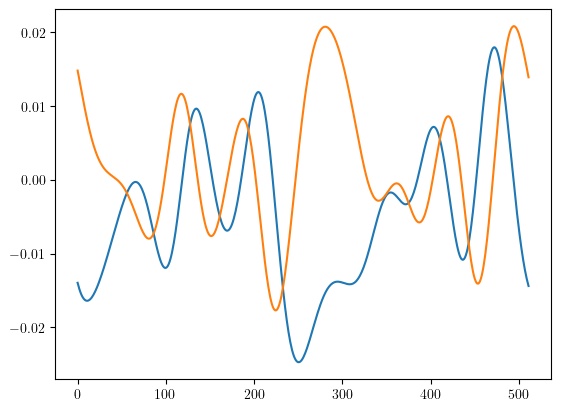

In [9]:
plt.plot(Re_res)
plt.plot(Im_res)

Text(0.5, 1.0, 'response amplitude')

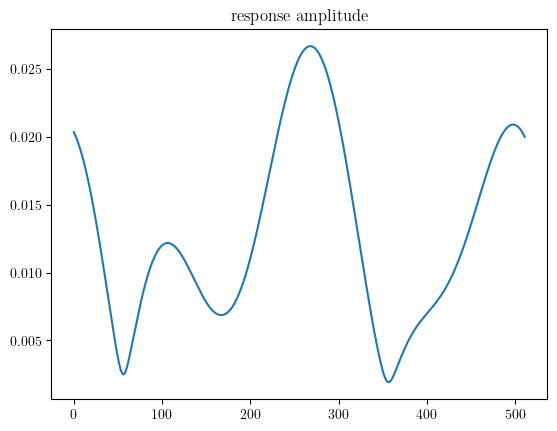

In [10]:
plt.plot(Amp_res)
plt.title("response amplitude")

Text(0.5, 1.0, 'response phase')

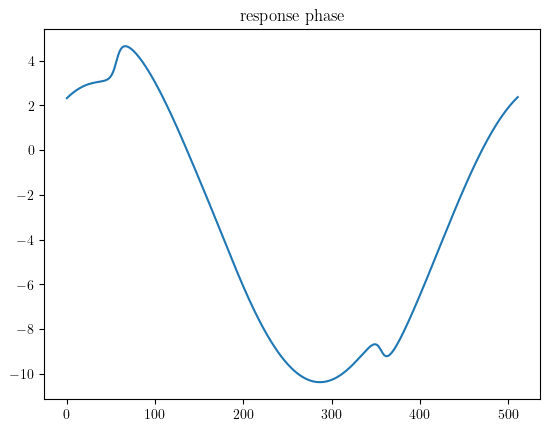

In [11]:
plt.plot(np.unwrap(Arg_res))
plt.title("response phase")

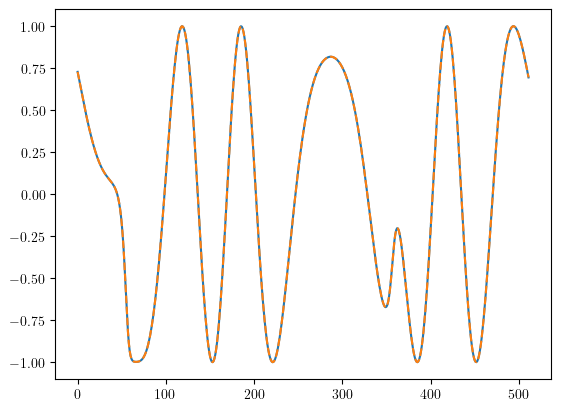

In [12]:
plt.plot(np.sin(Arg_res))
plt.plot(np.sin(np.unwrap(Arg_res)), linestyle="--")

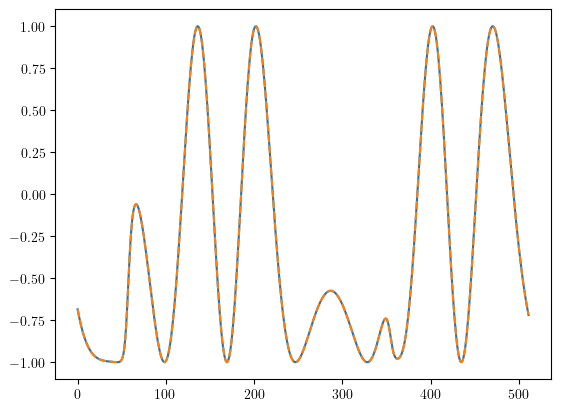

In [13]:
plt.plot(np.cos(Arg_res))
plt.plot(np.cos(np.unwrap(Arg_res)), linestyle="--")

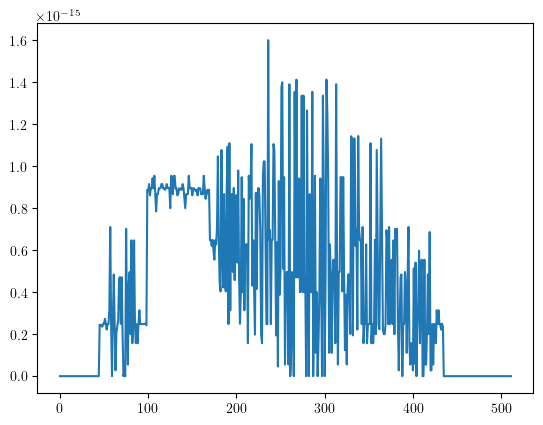

In [14]:
plt.plot(np.abs(np.exp(1.j * Arg_res) - np.exp(1.j * np.unwrap(Arg_res))))

/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/taijidatacenter/miniconda3/envs/tri_env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


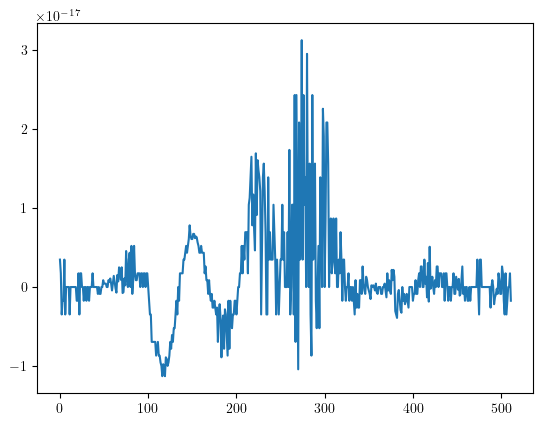

In [15]:
plt.plot(res[0] - Amp_res * np.exp(1.j * np.unwrap(Arg_res)))

(5000000.0, 5010000.0)

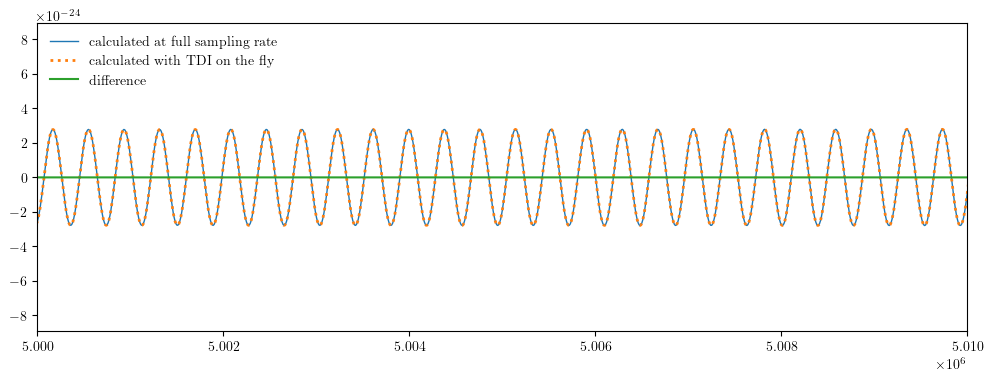

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(tcb_times, gen, linewidth=1, zorder=1, label="calculated at full sampling rate")
plt.plot(tcb_times, tdi_res, linestyle=":", linewidth=2, label="calculated with TDI on the fly")

plt.plot(tcb_times, gen - tdi_res, label="difference")

plt.legend(loc="upper left", frameon=False)
plt.xlim(0.5e7, 0.501e7)

(0.0026036699999999998, 0.00262367)

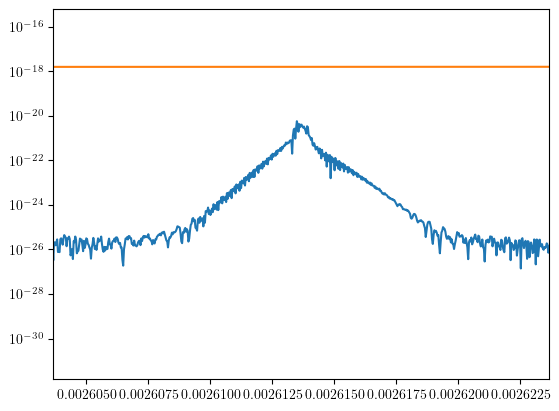

In [36]:
ff, xf = FFT_window(gen - tdi_res, 1./dt, window_type="tukey", window_args_dict=dict(alpha=0.1))
plt.semilogy(ff, np.abs(xf))
psdfunc = TDIPSDs()
plt.semilogy(ff, np.sqrt(psdfunc.PSD_X2(ff) * Tobs / 4.))
plt.xlim(GB_params["f0"] - 1e-5, GB_params["f0"] + 1e-5)